### Initial Analysis & MLE

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import spearmanr, norm
import datetime as dt

In [ ]:
# 2024-01-01 to 2026-01-01
df = pl.read_csv("SA-24-26.csv", try_parse_dates=True)

In [141]:
# average and standard deviation of price
df["RRP"].mean(), df["RRP"].std()

(75.53062499999999, 32.7756000507885)

In [142]:
print(df["RRP"].describe())

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 35040.0   │
│ null_count ┆ 0.0       │
│ mean       ┆ 75.530625 │
│ std        ┆ 32.7756   │
│ min        ┆ -51.8     │
│ 25%        ┆ 53.43     │
│ 50%        ┆ 75.81     │
│ 75%        ┆ 97.84     │
│ max        ┆ 205.94    │
└────────────┴───────────┘


In [143]:
# RRP going negative
neg = [rrp for rrp in df["RRP"] if rrp < 0]
print(f"Percentage of negative RRP values: {len(neg) / len(df['RRP']) * 100:.5f}%")

Percentage of negative RRP values: 1.14155%


In [144]:
monthly_negatives = (
    df.group_by("month")
    .agg(
        ((pl.col("RRP") < 0).sum() / pl.col("RRP").count() * 100).alias("Percentage Of Negative Timestamps")
    )
    .sort("month")
)

with pl.Config(tbl_rows=-1):
    print(monthly_negatives)

shape: (12, 2)
┌───────┬─────────────────────────────────┐
│ month ┆ Percentage Of Negative Timesta… │
│ ---   ┆ ---                             │
│ i64   ┆ f64                             │
╞═══════╪═════════════════════════════════╡
│ 1     ┆ 0.772849                        │
│ 2     ┆ 0.950292                        │
│ 3     ┆ 1.377688                        │
│ 4     ┆ 1.10957                         │
│ 5     ┆ 1.276882                        │
│ 6     ┆ 1.25                            │
│ 7     ┆ 1.71371                         │
│ 8     ┆ 1.176075                        │
│ 9     ┆ 1.145833                        │
│ 10    ┆ 1.076716                        │
│ 11    ┆ 0.9375                          │
│ 12    ┆ 0.887978                        │
└───────┴─────────────────────────────────┘


(array([19723., 19814., 19905., 19997., 20089., 20179., 20270., 20362.,
        20454.]),
 [Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10'),
  Text(20089.0, 0, '2025-01'),
  Text(20179.0, 0, '2025-04'),
  Text(20270.0, 0, '2025-07'),
  Text(20362.0, 0, '2025-10'),
  Text(20454.0, 0, '2026-01')])

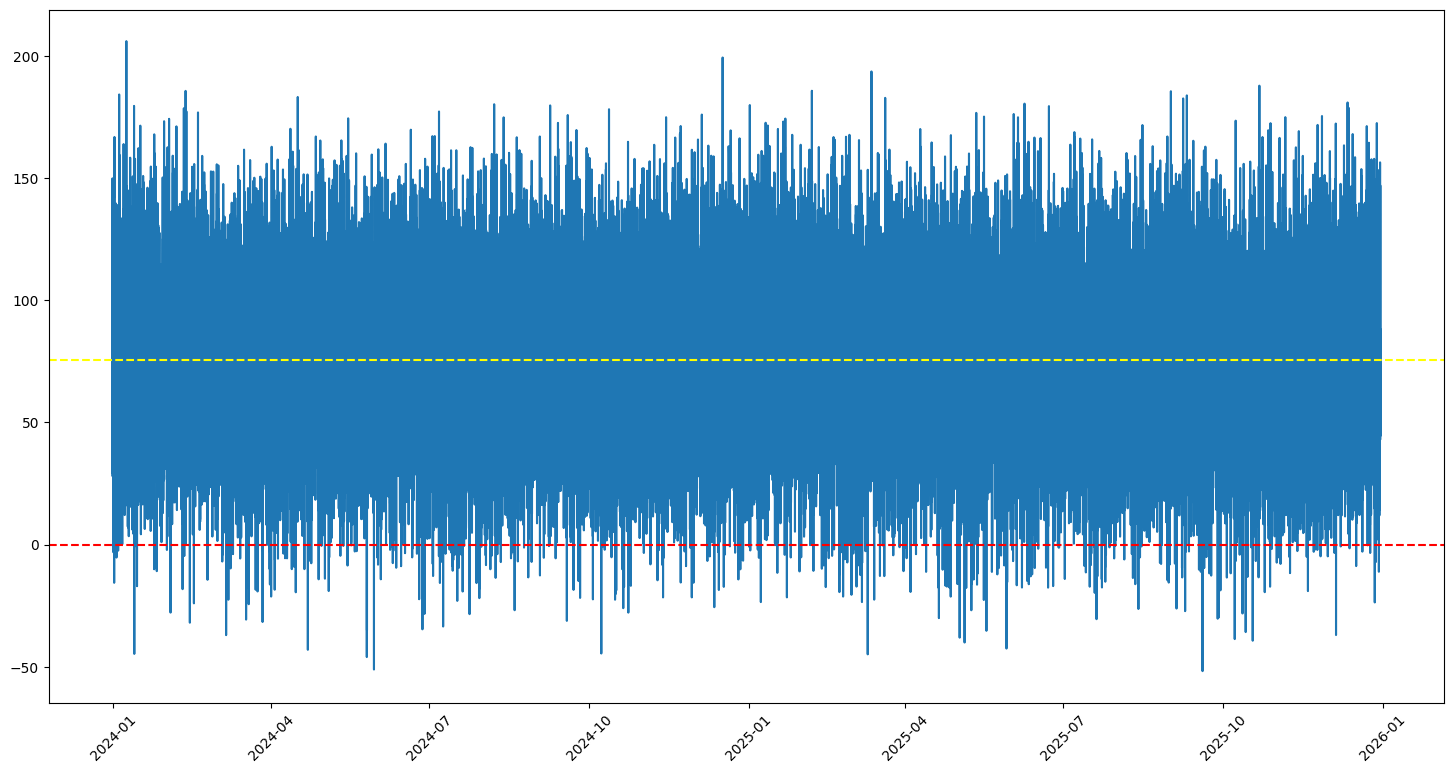

In [145]:
plt.figure(figsize=(18, 9))
plt.plot(df["SETTLEMENTDATE"], df["RRP"])
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.axhline(y = df["RRP"].mean(), color = 'yellow', linestyle = '--')
plt.xticks(rotation=45)

In [146]:
df = (df
    .with_columns((pl.col("TOTALDEMAND") ** 2).alias("TOTALDEMAND_SQ"))
    .with_columns((pl.col("TOTALDEMAND") ** 3).alias("TOTALDEMAND_CUBE"))
)

rrp_demand_model = smf.ols('RRP ~ TOTALDEMAND + TOTALDEMAND_SQ + TOTALDEMAND_CUBE', data=df).fit()
rrp_demand_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    RRP   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     318.2
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          7.60e-204
Time:                        21:55:51   Log-Likelihood:            -1.7153e+05
No. Observations:               35040   AIC:                         3.431e+05
Df Residuals:                   35036   BIC:                         3.431e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         -491.6851     31.427    -15.645      0.000    -553.284    -430.086
TOTALDEMAND          0.9181      0.051     18.120      0.000       0.819       1.017
TOTALDEMAND_SQ      -0.0005   2.69e-05    -17.843      0.000      -0.001      -0.000
TOTALDEMAND_CUBE  8.066e-08   4.68e-09     17.235      0.000    7.15e-08    8.98e-08
==============================================================================
Omnibus:                        4.548   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.103   Jarque-Bera (JB):                4.501
Skew:                          -0.018   Prob(JB):                        0.105
Kurtosis:                       2.959   Cond. No.                     1.36e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.36e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [147]:
rrp_demand_model.rsquared # terrible R^2 value

np.float64(0.02652236037844591)

Text(0.5, 1.0, 'RRP vs Total Demand with Trendline')

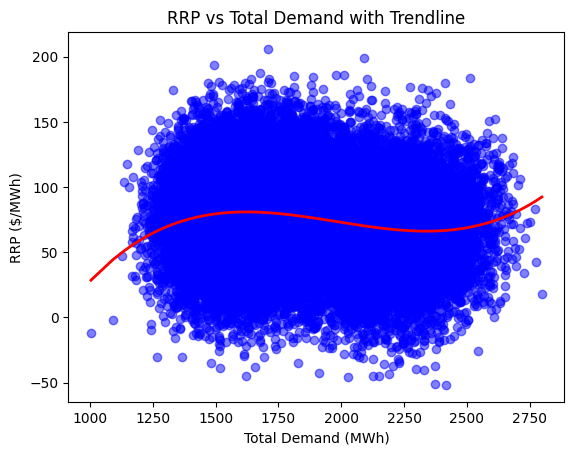

In [148]:
sorted_demand = (
    df.select("TOTALDEMAND")
    .sort("TOTALDEMAND")
    .with_columns((pl.col("TOTALDEMAND") ** 2).alias("TOTALDEMAND_SQ"))
    .with_columns((pl.col("TOTALDEMAND") ** 3).alias("TOTALDEMAND_CUBE"))
)

predicted_rrp = rrp_demand_model.predict(sorted_demand.to_pandas())

plt.scatter(df["TOTALDEMAND"].to_pandas(), df["RRP"].to_pandas(), alpha=0.5, label="Actual Data", color="blue")
plt.plot(sorted_demand["TOTALDEMAND"].to_pandas(), predicted_rrp, color="red", linewidth=2, label="Quadratic Trendline")
plt.xlabel("Total Demand (MWh)")
plt.ylabel("RRP ($/MWh)")
plt.title("RRP vs Total Demand with Trendline")

Text(0.5, 1.0, 'Distribution RRP')

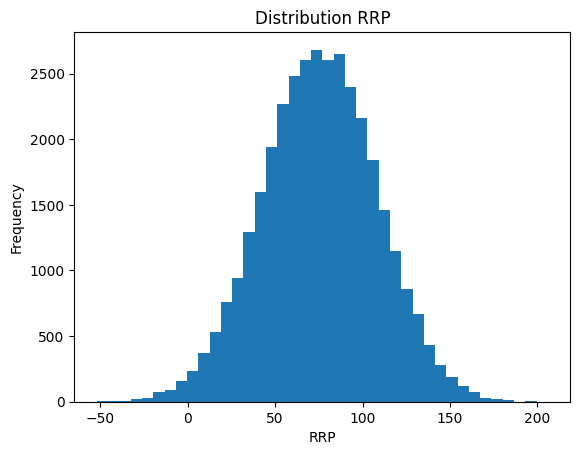

In [149]:
plt.hist(df["RRP"], bins=40)
plt.xlabel("RRP")
plt.ylabel("Frequency")
plt.title("Distribution RRP")

In [150]:
a, loc, scale = stats.gamma.fit(df["RRP"])

In [151]:
correlation, p_value = stats.spearmanr(df["RRP"], df["TOTALDEMAND"])

correlation, p_value

(np.float64(-0.11059509090378532), np.float64(8.92566777589553e-96))

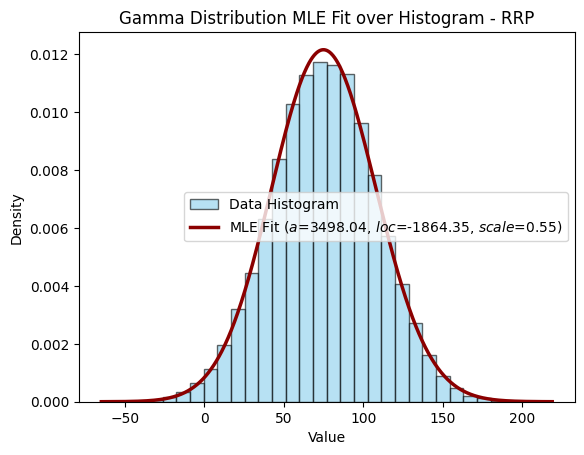

In [152]:
plt.hist(df["RRP"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')

x_min, x_max = plt.xlim()
x_axis = np.linspace(x_min, x_max, 1000)
fitted_pdf_gamma = stats.gamma.pdf(x_axis, a, loc, scale)

plt.plot(x_axis, fitted_pdf_gamma, color='darkred', linewidth=2.5, label=fr'MLE Fit ($a$={a:.2f}, $loc$={loc:.2f}, $scale$={scale:.2f})')

# 4. Final adjustments
plt.title('Gamma Distribution MLE Fit over Histogram - RRP')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

Text(0.5, 1.0, 'RRP Percentage Change Over Time')

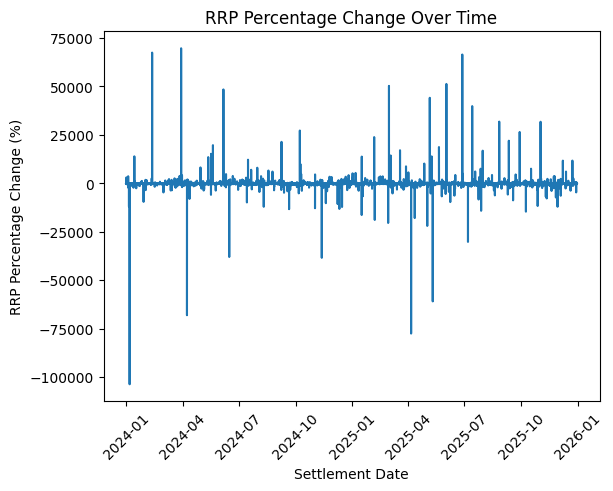

In [153]:
plt.plot(df["SETTLEMENTDATE"], df["rrp_pct_change"])
plt.xticks(rotation=45)
plt.xlabel("Settlement Date")
plt.ylabel("RRP Percentage Change (%)")
plt.title("RRP Percentage Change Over Time")

Text(0.5, 1.0, 'Distribution of RRP Changes')

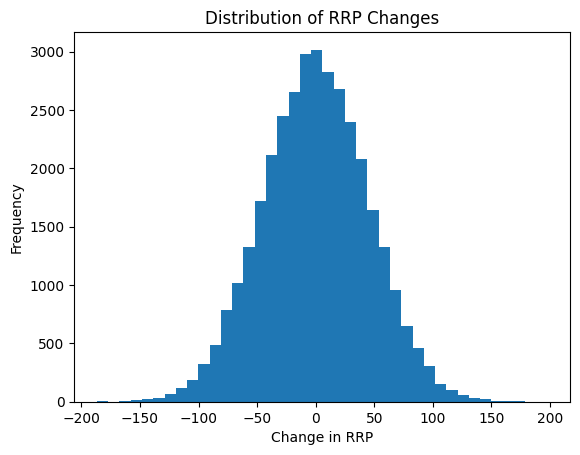

In [154]:
plt.hist(df["change_rrp"], bins=40)
plt.xlabel("Change in RRP")
plt.ylabel("Frequency")
plt.title("Distribution of RRP Changes")

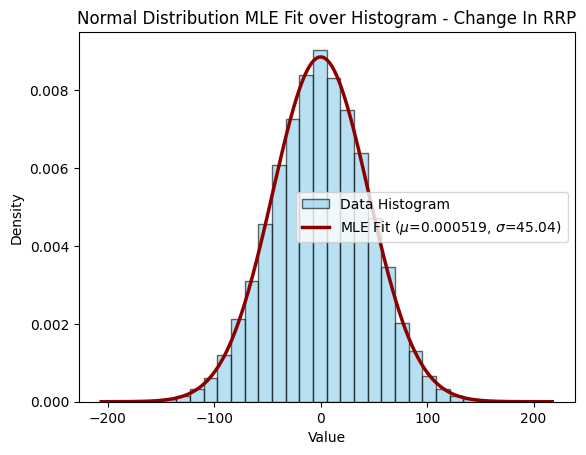

In [155]:
mu, sigma = stats.norm.fit(df["change_rrp"])

plt.hist(df["change_rrp"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')

x_min, x_max = plt.xlim()
x_axis = np.linspace(x_min, x_max, 1000)
fitted_pdf_norm = stats.norm.pdf(x_axis, mu, sigma)

plt.plot(x_axis, fitted_pdf_norm, color='darkred', linewidth=2.5, label=fr'MLE Fit ($\mu$={mu:.6f}, $\sigma$={sigma:.2f})')

# 4. Final adjustments
plt.title('Normal Distribution MLE Fit over Histogram - Change In RRP')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

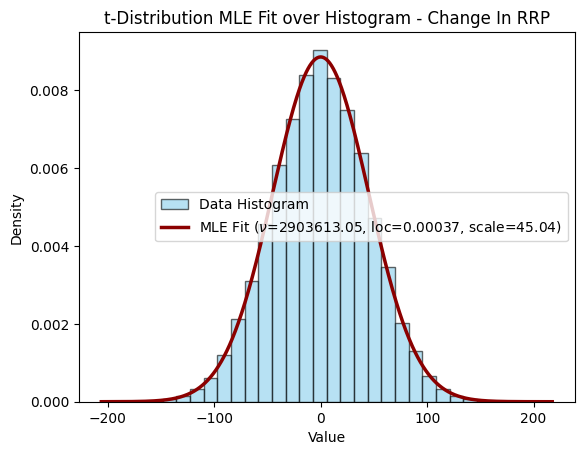

In [156]:
nu, loc, scale = stats.t.fit(df["change_rrp"])
nu, loc, scale

plt.hist(df["change_rrp"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')

x_min, x_max = plt.xlim()
x_axis = np.linspace(x_min, x_max, 1000)
fitted_pdf_t = stats.t.pdf(x_axis, nu, loc, scale)

plt.plot(x_axis, fitted_pdf_t, color='darkred', linewidth=2.5, label=fr'MLE Fit ($\nu$={nu:.2f}, loc={loc:.5f}, scale={scale:.2f})')

# 4. Final adjustments
plt.title('t-Distribution MLE Fit over Histogram - Change In RRP')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

## we see from high nu value essentially identical to normal distribution

In [157]:
stats.skew(df["change_rrp"]), stats.kurtosis(df["change_rrp"])

(np.float64(-0.008952000908756122), np.float64(-0.015755279789447574))

In [158]:
print(df["change_rrp"].describe())

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 35040.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.000519 │
│ std        ┆ 45.03703 │
│ min        ┆ -186.76  │
│ 25%        ┆ -30.49   │
│ 50%        ┆ -0.02    │
│ 75%        ┆ 30.77    │
│ max        ┆ 198.24   │
└────────────┴──────────┘


### MODELLING NAIVELY

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = df.sort("SETTLEMENTDATE")

feature_cols = [c for c in df.columns if c not in ["RRP", "positive_price", "SETTLEMENTDATE"]]

# we want to use previous timestep data and try to predict for next timestep
X_lagged = df.select(pl.col(feature_cols).shift(1))
y_series = df["positive_price"]

# since first row returns NaN
X_clean = X_lagged[1:]
y_clean = y_series[1:]

X = X_clean.to_numpy()
y = y_clean.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

log_regression_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_regression_model.fit(X_train, y_train)

print(classification_report(y_test, log_regression_model.predict(X_test)))

# we see log regression is terrible for predicting the rare event of negative prices

              precision    recall  f1-score   support

           0       0.02      0.46      0.03        80
           1       0.99      0.71      0.83      6928

    accuracy                           0.71      7008
   macro avg       0.50      0.59      0.43      7008
weighted avg       0.98      0.71      0.82      7008



In [170]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = df.sort("SETTLEMENTDATE")

feature_cols = [c for c in df.columns if c not in ["RRP", "positive_price", "SETTLEMENTDATE"]]

features_df = df.select([
    # Base features from previous step (t-1)
    pl.col(feature_cols).shift(1).name.suffix("_lag1"),
    
    # 3-step rolling average to capture short-term momentum
    pl.col(feature_cols).shift(1).rolling_mean(window_size=3).name.suffix("_roll_mean3"),

    # 5-step rolling average to capture slightly longer-term trends
    pl.col(feature_cols).shift(1).rolling_mean(window_size=5).name.suffix("_roll_mean5")
])

# Add target back, drop rows with NaN values caused by shifting/rolling
ml_df = pl.concat([features_df, df.select("positive_price")], how="horizontal").drop_nulls()

X = ml_df.drop("positive_price").to_numpy()
y = ml_df["positive_price"].to_numpy()

# no shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

hgb_model.fit(X_train, y_train)

print(classification_report(y_test, hgb_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.02      0.33      0.04        80
           1       0.99      0.82      0.90      6927

    accuracy                           0.82      7007
   macro avg       0.51      0.57      0.47      7007
weighted avg       0.98      0.82      0.89      7007



### MODELLING 1 - Basic & Quantile Focussed Gradient Boosting Regressor On Price

In [171]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = df.sort("SETTLEMENTDATE")

feature_cols = [c for c in df.columns if c not in ["RRP", "positive_price", "SETTLEMENTDATE", "price_last_step"]]

features_df = df.select([
    # base features from previous step (t-1)
    pl.col(feature_cols).shift(1).name.suffix("_lag1"),
    
    # 3-step rolling average to capture short-term momentum
    pl.col(feature_cols).shift(1).rolling_mean(window_size=3).name.suffix("_roll_mean3"),

    # 5-step rolling average to capture slightly longer-term trends
    pl.col(feature_cols).shift(1).rolling_mean(window_size=5).name.suffix("_roll_mean5")
])

# add target and price_last_step, drop rows with NaN values caused by shifting/rolling
ml_df = pl.concat([features_df, df.select(["RRP", "price_last_step"])], how="horizontal").drop_nulls()

X = ml_df.drop(["RRP"]).to_numpy()
y = ml_df["RRP"].to_numpy()

# no shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

In [172]:
reg_model = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, random_state=42)
reg_model.fit(X_train, y_train)

predicted_prices = reg_model.predict(X_test)

In [208]:
df_testresults = pl.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': predicted_prices,
    'Residual': y_test - predicted_prices
})

print(df_testresults.describe())

shape: (9, 4)
┌────────────┬──────────────┬─────────────────┬─────────────┐
│ statistic  ┆ Actual_Price ┆ Predicted_Price ┆ Residual    │
│ ---        ┆ ---          ┆ ---             ┆ ---         │
│ str        ┆ f64          ┆ f64             ┆ f64         │
╞════════════╪══════════════╪═════════════════╪═════════════╡
│ count      ┆ 8759.0       ┆ 8759.0          ┆ 8759.0      │
│ null_count ┆ 0.0          ┆ 0.0             ┆ 0.0         │
│ mean       ┆ 75.063207    ┆ 74.909159       ┆ 0.154048    │
│ std        ┆ 33.154556    ┆ 6.976923        ┆ 32.390485   │
│ min        ┆ -51.8        ┆ 52.526124       ┆ -119.584376 │
│ 25%        ┆ 52.82        ┆ 68.80157        ┆ -21.934991  │
│ 50%        ┆ 75.72        ┆ 77.217832       ┆ 0.33715     │
│ 75%        ┆ 97.79        ┆ 80.333864       ┆ 22.202851   │
│ max        ┆ 187.72       ┆ 91.600479       ┆ 117.226236  │
└────────────┴──────────────┴─────────────────┴─────────────┘


(50.0, 100.0)

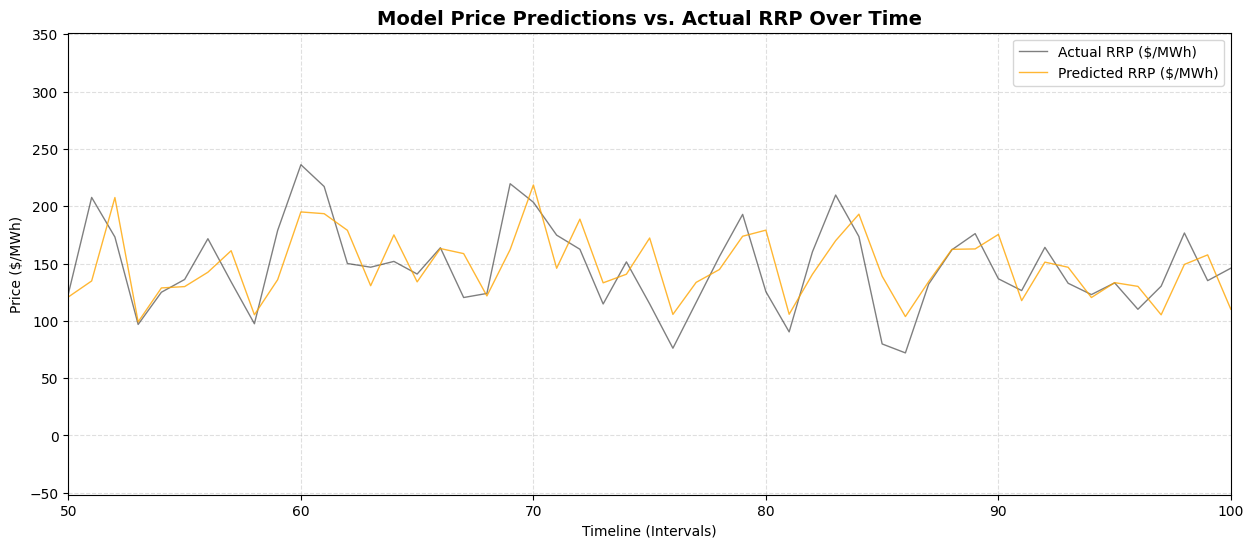

In [188]:
true_rrp = price_last_step + y_test
predicted_rrp = price_last_step + predicted_prices

timeline = np.arange(len(true_rrp))

plt.figure(figsize=(15, 6))
plt.plot(timeline, true_rrp, label="Actual RRP ($/MWh)", color="black", alpha=0.5, linewidth=1)
plt.plot(timeline, predicted_rrp, label="Predicted RRP ($/MWh)", color="orange", alpha=0.8, linewidth=1)

plt.title("Model Price Predictions vs. Actual RRP Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Timeline (Intervals)")
plt.ylabel("Price ($/MWh)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(50, 100)

In [389]:
from sklearn.ensemble import HistGradientBoostingRegressor

# train model that looks explicitly at the bottom 15% worst-case price scenarios
quantile_model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.15, # 15th percentile
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

quantile_model.fit(X_train, y_train)

predicted_quantile_prices = quantile_model.predict(X_test)

df_quantile = pl.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': predicted_quantile_prices,
})

print(df_quantile.describe())

shape: (9, 3)
┌────────────┬──────────────┬─────────────────┐
│ statistic  ┆ Actual_Price ┆ Predicted_Price │
│ ---        ┆ ---          ┆ ---             │
│ str        ┆ f64          ┆ f64             │
╞════════════╪══════════════╪═════════════════╡
│ count      ┆ 8759.0       ┆ 8759.0          │
│ null_count ┆ 0.0          ┆ 0.0             │
│ mean       ┆ 75.063207    ┆ 42.723397       │
│ std        ┆ 33.154556    ┆ 6.528721        │
│ min        ┆ -51.8        ┆ 20.203208       │
│ 25%        ┆ 52.82        ┆ 37.739337       │
│ 50%        ┆ 75.72        ┆ 45.05594        │
│ 75%        ┆ 97.79        ┆ 47.804239       │
│ max        ┆ 187.72       ┆ 54.511491       │
└────────────┴──────────────┴─────────────────┘


In [201]:
from sklearn.metrics import classification_report, confusion_matrix

# classify based on the natural zero threshold ( < 0 is a sub-zero event)
binary_predictions = (predicted_quantile_prices < 0).astype(int)

# derive the ground truth directly from Actual_Price on the fly
binary_actual = (df_quantile["Actual_Price"].to_numpy() < 0).astype(int)

In [202]:
print(classification_report(binary_actual, binary_predictions, target_names=["Above Zero", "Sub-Zero"]))

              precision    recall  f1-score   support

  Above Zero       0.99      0.99      0.99      8658
    Sub-Zero       0.03      0.04      0.03       101

    accuracy                           0.97      8759
   macro avg       0.51      0.51      0.51      8759
weighted avg       0.98      0.97      0.98      8759



In [203]:
print("Confusion Matrix")
print(confusion_matrix(binary_actual, binary_predictions))

Confusion Matrix
[[8534  124]
 [  97    4]]


In [261]:
## look at most important variables here...

### MODELLING PRICE CHANGES

In [222]:
df = df.sort("SETTLEMENTDATE")

feature_cols_change = [c for c in df.columns if c not in ["SETTLEMENTDATE", "price_last_step", "change_rrp"]]

features_change_df = df.select([
    # base features from previous step (t-1)
    pl.col(feature_cols).shift(1).name.suffix("_lag1"),
    
    # 3-step rolling average to capture short-term momentum
    pl.col(feature_cols).shift(1).rolling_mean(window_size=3).name.suffix("_roll_mean3"),

    # 5-step rolling average to capture slightly longer-term trends
    pl.col(feature_cols).shift(1).rolling_mean(window_size=5).name.suffix("_roll_mean5")
])


# add target and price_last_step, drop rows with NaN values caused by shifting/rolling
ml_change_df = pl.concat([features_df, df.select(["change_rrp", "price_last_step"])], how="horizontal").drop_nulls()

X_change = ml_change_df.drop(["change_rrp"]).to_numpy()
y_change = ml_change_df["change_rrp"].to_numpy()

# no shuffling
X_train_change, X_test_change, y_train_change, y_test_change = train_test_split(X_change, y_change, test_size=0.2, shuffle=False)

In [212]:
reg_model_change = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, random_state=42)
reg_model_change.fit(X_train_change, y_train_change)

predicted_change = reg_model_change.predict(X_test_change)

In [214]:
df_change_testresults = pl.DataFrame({
    'Actual_Change': y_test_change,
    'Predicted_Change': predicted_change,
    'Residual_Change': y_test_change - predicted_change
})

print(df_change_testresults.describe())

shape: (9, 4)
┌────────────┬───────────────┬──────────────────┬─────────────────┐
│ statistic  ┆ Actual_Change ┆ Predicted_Change ┆ Residual_Change │
│ ---        ┆ ---           ┆ ---              ┆ ---             │
│ str        ┆ f64           ┆ f64              ┆ f64             │
╞════════════╪═══════════════╪══════════════════╪═════════════════╡
│ count      ┆ 7007.0        ┆ 7007.0           ┆ 7007.0          │
│ null_count ┆ 0.0           ┆ 0.0              ┆ 0.0             │
│ mean       ┆ -0.005042     ┆ -0.306193        ┆ 0.301151        │
│ std        ┆ 44.997303     ┆ 31.57291         ┆ 32.437706       │
│ min        ┆ -153.58       ┆ -102.661171      ┆ -126.787796     │
│ 25%        ┆ -30.24        ┆ -22.549566       ┆ -21.743937      │
│ 50%        ┆ 0.44          ┆ -0.300513        ┆ 0.443328        │
│ 75%        ┆ 30.56         ┆ 21.062679        ┆ 22.244844       │
│ max        ┆ 170.24        ┆ 95.327721        ┆ 121.970473      │
└────────────┴───────────────┴────

In [217]:
# classify based on the natural zero threshold ( < 0 is a sub-zero event)
binary_predictions_change = (predicted_change < 0).astype(int)

# derive the ground truth directly from Actual_Price on the fly
binary_actual_change = (df_change_testresults["Actual_Change"].to_numpy() < 0).astype(int)

In [219]:
print(classification_report(binary_actual_change, binary_predictions_change, target_names=["Above Zero", "Sub-Zero"]))

              precision    recall  f1-score   support

  Above Zero       0.75      0.74      0.74      3531
    Sub-Zero       0.74      0.75      0.74      3476

    accuracy                           0.74      7007
   macro avg       0.74      0.74      0.74      7007
weighted avg       0.74      0.74      0.74      7007



In [220]:
print("Confusion Matrix")
print(confusion_matrix(binary_actual, binary_predictions))

Confusion Matrix
[[8534  124]
 [  97    4]]


(50.0, 100.0)

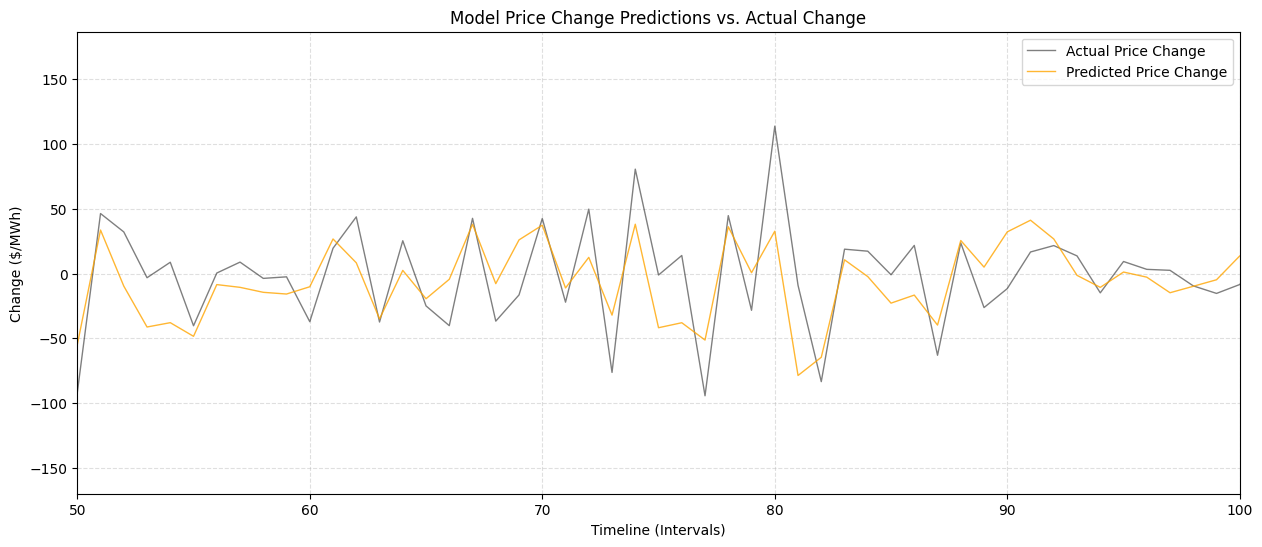

In [221]:
timeline = np.arange(len(y_test_change))

plt.figure(figsize=(15, 6))
plt.plot(timeline, y_test_change, label="Actual Price Change", color="black", alpha=0.5, linewidth=1)
plt.plot(timeline, predicted_change, label="Predicted Price Change", color="orange", alpha=0.8, linewidth=1)

plt.title("Model Price Change Predictions vs. Actual Change")
plt.xlabel("Timeline (Intervals)")
plt.ylabel("Change ($/MWh)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(50, 100)

In [ ]:
from sklearn.inspection import permutation_importance

result_change = permutation_importance(
    reg_model_change,
    X_train_change,
    y_train_change,
    n_repeats=10,
    random_state=42
)
importances_change = result_change.importances_mean

array([2.10693719e-03, 1.58183916e-03, 1.22254539e-03, 1.31778345e-03,
       9.79020169e-04, 5.51156695e-04, 1.08539983e-03, 8.53317838e-04,
       1.20301820e-03, 6.60520680e-04, 9.19992124e-04, 1.15802706e-03,
       2.54889053e-03, 1.55991899e-03, 3.18483965e-03, 2.16403002e-03,
       2.96267194e-04, 9.10951068e-04, 8.65109660e-04, 3.00058863e-04,
       2.53868549e-04, 9.67131761e-04, 0.00000000e+00, 8.92430352e-05,
       0.00000000e+00, 0.00000000e+00, 1.41331426e-03, 1.62281676e-03,
       3.27464810e-03, 2.35722457e-03, 1.19084213e-03, 5.85914312e-04,
       3.80567935e-04, 1.05456009e-03, 8.99548349e-04, 5.68360340e-04,
       7.43147193e-04, 8.96261568e-04, 1.19661402e-03, 2.44775092e-03,
       7.25437550e-04, 4.72524758e-03, 9.29274494e-04, 8.02083870e-04,
       1.20249303e-03, 2.22059533e-03, 1.31463916e-03, 3.10818885e-04,
       7.24217480e-04, 6.92340150e-04, 1.27258778e-04, 2.38274090e-04,
       6.99035082e-04, 8.93670886e-04, 2.91604063e-04, 2.29240046e-03,
      

### MODEL SENSITIVE FOR PREDICTING NEGATIVE CHANGE (QUANTILE)

In [390]:
change_quantile_model = HistGradientBoostingRegressor(
    loss="quantile",
    quantile=0.15, # 15th percentile
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

change_quantile_model.fit(X_train_change, y_train_change)

predicted_quantile_change = change_quantile_model.predict(X_test_change)

df_quantile_change_testresults = pl.DataFrame({
    'Actual_Change': y_test_change,
    'Predicted_Change': predicted_quantile_change,
})

print(df_quantile_change_testresults.describe())

shape: (9, 3)
┌────────────┬───────────────┬──────────────────┐
│ statistic  ┆ Actual_Change ┆ Predicted_Change │
│ ---        ┆ ---           ┆ ---              │
│ str        ┆ f64           ┆ f64              │
╞════════════╪═══════════════╪══════════════════╡
│ count      ┆ 7007.0        ┆ 7007.0           │
│ null_count ┆ 0.0           ┆ 0.0              │
│ mean       ┆ -0.005042     ┆ -32.519133       │
│ std        ┆ 44.997303     ┆ 30.637159        │
│ min        ┆ -153.58       ┆ -125.296572      │
│ 25%        ┆ -30.24        ┆ -54.523165       │
│ 50%        ┆ 0.44          ┆ -34.170968       │
│ 75%        ┆ 30.56         ┆ -11.304023       │
│ max        ┆ 170.24        ┆ 48.838238        │
└────────────┴───────────────┴──────────────────┘


In [243]:
binary_predictions_quantile_change = (predicted_quantile_change < 0).astype(int)
binary_actual_quantile_change = (df_quantile_change_testresults["Actual_Change"].to_numpy() < 0).astype(int)

In [244]:
# how good at predicting price going up or down, irrespective of magnitude
print(classification_report(binary_actual_quantile_change, binary_predictions_quantile_change, target_names=["Above Zero", "Sub-Zero"]))

              precision    recall  f1-score   support

  Above Zero       0.92      0.29      0.44      3531
    Sub-Zero       0.57      0.98      0.72      3476

    accuracy                           0.63      7007
   macro avg       0.75      0.63      0.58      7007
weighted avg       0.75      0.63      0.58      7007



In [250]:
result_quantile_change = permutation_importance(
    change_quantile_model,
    X_train_change,
    y_train_change,
    n_repeats=10,
    random_state=42
)
importances_quantile_change = result_quantile_change.importances_mean

### ANALYSING IMPORTANT PREDICTOR VARIABLES IN MODEL(S)

In [260]:
# actual features has 81 cols, importances change (both) has 82 (FIX)

actual_features = [col for col in ml_df.columns if col not in ["RRP", "price_last_step"]]

importance_df = pl.DataFrame({
    "Feature": actual_features,
    "Importance Standard": importances_change[1:], # not including first entry
    "Importance Quantile": importances_quantile_change[1:] # not including first entry
}).sort("Importance Quantile", descending=True)

print("Top Drivers of Sub-Zero Market Risk (sorted by Importance Quantile descending)")
print(importance_df.head(10))

Top Drivers of Sub-Zero Market Risk (sorted by Importance Quantile descending)
shape: (10, 3)
┌──────────────────────────────┬─────────────────────┬─────────────────────┐
│ Feature                      ┆ Importance Standard ┆ Importance Quantile │
│ ---                          ┆ ---                 ┆ ---                 │
│ str                          ┆ f64                 ┆ f64                 │
╞══════════════════════════════╪═════════════════════╪═════════════════════╡
│ rrp_pct_change_roll_mean5    ┆ 0.981972            ┆ 0.918676            │
│ TOTALDEMAND_lag1             ┆ 0.001582            ┆ 0.009916            │
│ gen_solar_rooftop_roll_mean5 ┆ 0.002125            ┆ 0.007424            │
│ demand_trend_roll_mean3      ┆ 0.001202            ┆ 0.006019            │
│ demand_trend_roll_mean5      ┆ 0.001167            ┆ 0.005948            │
│ gen_solar_rooftop_lag1       ┆ 0.001223            ┆ 0.00535             │
│ demand_previous_roll_mean5   ┆ 0.001647            ┆ 0.00

We see recent fluctuations in price are a massive predictor of subzero prices. Features like recent demand and rooftop solar generation indicate potential storage available in the grid and give indication if it is close to being drained/overfilled (since SA has a lot of rooftop solar this showcases its relevance in the market). 

### VOLATILITY

Even though it seems electrcity price volatility is somewhat non sticky, should come up with features for demand and rrp volatility. Also prove why it is non sticky (eg Garch etc)

Want to prioritise recall - ie we may get some false alarms for prices being negative, but do want to miss predicting when they do go negative 

In [ ]:
from arch import arch_model

model_rrp = arch_model(df["RRP"], vol='Garch', p=1, q=1, dist='t')  
fit_rrp = model_rrp.fit(disp='off')
# print(fit_rrp.summary())

In [ ]:
model_change_rrp = arch_model(df["change_rrp"], vol='Garch', p=1, q=1, dist='t')  
fit_change_rrp = model_change_rrp.fit(disp='off')
# print(fit_change_rrp.summary())

In [ ]:
model_demand_vol = arch_model(df["demand_vol"], vol='Garch', p=1, q=1, dist='t')  
fit_demand_vol = model_demand_vol.fit(disp='off')
# print(fit_demand_vol.summary())

In [ ]:
model_rrp_vol = arch_model(df["rrp_vol"], vol='Garch', p=1, q=1, dist='t')  
fit_rrp_vol = model_rrp_vol.fit(disp='off')
# print(fit_rrp_vol.summary())

In [ ]:
# alpha - shock sensitivity
# beta - memory persistence

garch_results = pl.DataFrame({
    "Model": ["RRP", "Change in RRP", "Demand Volatility", "RRP Volatility"], 
    "p-value alpha": [fit_rrp.pvalues["alpha[1]"], fit_change_rrp.pvalues["alpha[1]"], fit_demand_vol.pvalues["alpha[1]"], fit_rrp_vol.pvalues["alpha[1]"]],
    "p-value beta": [fit_rrp.pvalues["beta[1]"], fit_change_rrp.pvalues["beta[1]"], fit_demand_vol.pvalues["beta[1]"], fit_rrp_vol.pvalues["beta[1]"]],
    "alpha": [fit_rrp.params["alpha[1]"], fit_change_rrp.params["alpha[1]"], fit_demand_vol.params["alpha[1]"], fit_rrp_vol.params["alpha[1]"]],
    "beta": [fit_rrp.params["beta[1]"], fit_change_rrp.params["beta[1]"], fit_demand_vol.params["beta[1]"], fit_rrp_vol.params["beta[1]"]]
})

garch_results

Model,p-value alpha,p-value beta,alpha,beta
str,f64,f64,f64,f64
"""RRP""",0.108298,0.142737,0.010588,0.502016
"""Change in RRP""",2.5724e-244,1.0,0.247304,0.0
"""Demand Volatility""",0.0,1.0,0.96597,3.6705e-9
"""RRP Volatility""",0.0,1.0,0.8178,0.0


Note the p values for alpha and beta just show that the results and hence conclusions from the alpha and beta values are statistically significant. 

We notice from the table that electricity prices dont experience the same volatility drag that might be found in the stockmarket (evidenced by very low beta value). Here the volatility is not sticky, and market memory is short. The volatility in the price is driven by physical shocks (high alpha value). 

This also explains why the tree based decision tree is works reasomably as a predictor since it can deal with discontinuities and fast changes to the price. 

### SIMULATION OF BATTERY CHARGING & BASIC STRATEGY

Modelling potential strategy with a battery aiming to charge when prices go negative. 

In [504]:
price_last_step_cleaned = ml_change_df["price_last_step"].to_numpy()

# slice the exact number of test rows from the end (since shuffle=False), so that matches to test set
test_row_count = len(df_change_testresults)  # this will be 7007
price_last_step_test = price_last_step_cleaned[-test_row_count:]

actual_prices_sim = price_last_step_test + df_change_testresults["Actual_Change"].to_numpy()
predicted_prices_sim = price_last_step_test + df_change_testresults["Predicted_Change"].to_numpy()

In [734]:
# backtesting for each time interval in the test set
# note that we could signficantly optimise our selling/discharging model since the logic currently is incredibly basic
# also further optimisation, improvement of the charging model is possible

def battery_simulation(actual_prices_sim, predicted_prices_sim, price_last_step_test):
    

    MAX_CAPACITY = 5        # MWh
    MAX_POWER = 1.0         # MW
    INTERVAL = 0.5          # every 30 minutes (0.5 hours)
    ENERGY_STEP = MAX_POWER * INTERVAL # 0.5 MWh per interval (half hour)
    RE_EFFICIENCY = 1    # 90% round-trip efficiency factor


    # simulation variables
    soc = 0.0               # battery current state of charge (starts empty)
    total_earnings = 0.0    # wealth over time
    actions = []            # maintain log
    soc_history = []        # tracking battery level over time
    profit_history = []     # tracking cumulative profit over time


    for actual, pred, price_lag1 in zip(actual_prices_sim, predicted_prices_sim, price_last_step_test):

        estimated_price = pred + price_lag1

        action = "HOLD"
        
        # model predicts negative price - CHARGE
        if pred < -20 and soc < MAX_CAPACITY:

            charge_amount = min(ENERGY_STEP, MAX_CAPACITY - soc) # how much capacity left
            soc += charge_amount * RE_EFFICIENCY

            # subtract cost since price is negative (so getting paid to charge)
            total_earnings -= (charge_amount * actual)
            action = "CHARGE"
            
        # model not predicting negative price, and last price was above 60 - DISCHARGE
        elif price_lag1 > 70.0 and soc > 0:

            discharge_amount = min(ENERGY_STEP, soc)
            soc -= discharge_amount
            total_earnings += (discharge_amount * actual)
            action = "DISCHARGE"
            
        actions.append(action)
        soc_history.append(soc)
        profit_history.append(total_earnings)

    return actions, soc_history, profit_history



In [735]:
# # for converting change in price model back to actual price, prediction

# actions, soc_history, profit_history = battery_simulation(actual_prices_sim, predicted_prices_sim, price_last_step_test_sim)

In [736]:
price_last_step_cleaned = ml_change_df["price_last_step"].to_numpy()

test_row_count = len(df_change_testresults)
price_last_step_test = price_last_step_cleaned[-test_row_count:]

actual_change = df_change_testresults["Actual_Change"].to_numpy()
actual_prices_sim = price_last_step_test + df_change_testresults["Actual_Change"].to_numpy()

predicted_change_sim = df_change_testresults["Predicted_Change"].to_numpy()

In [737]:
# this is for predicting price change and trading on that information
actions, soc_history, profit_history = battery_simulation(actual_prices_sim, predicted_change_sim, price_last_step_test)

In [738]:
summary_df = pl.DataFrame({
    "Battery_Action": actions,
    "State_of_Charge": soc_history,
    "Cumulative_Profit": profit_history,
    "Actual_Price": actual_prices_sim
})

In [739]:
print("Grid battery simulation results:\n")
print(f"  Total trading profit: ${profit_history[-1]:,.2f}")
print(f"  Total charging events triggered: {actions.count('CHARGE')}")
print(f"  Total discharging events triggered: {actions.count('DISCHARGE')}")
print(f"  Total hold events: {actions.count('HOLD')}")
print(f"  Total number of events/timestamps simulated: {len(actions)}")
print(f"  Final state of charge: {soc_history[-1]:.2f} MWh")

print("\nFirst 10 intervals of simulation snapshot:")
print(summary_df.select(["Battery_Action", "State_of_Charge", "Cumulative_Profit"]).head(10))

Grid battery simulation results:

  Total trading profit: $2,083.08
  Total charging events triggered: 1843
  Total discharging events triggered: 1836
  Total hold events: 3328
  Total number of events/timestamps simulated: 7007
  Final state of charge: 3.50 MWh

First 10 intervals of simulation snapshot:
shape: (10, 3)
┌────────────────┬─────────────────┬───────────────────┐
│ Battery_Action ┆ State_of_Charge ┆ Cumulative_Profit │
│ ---            ┆ ---             ┆ ---               │
│ str            ┆ f64             ┆ f64               │
╞════════════════╪═════════════════╪═══════════════════╡
│ CHARGE         ┆ 0.5             ┆ -42.565           │
│ DISCHARGE      ┆ 0.0             ┆ 15.89             │
│ CHARGE         ┆ 0.5             ┆ -23.455           │
│ DISCHARGE      ┆ 0.0             ┆ 37.715            │
│ CHARGE         ┆ 0.5             ┆ -10.69            │
│ DISCHARGE      ┆ 0.0             ┆ 32.235            │
│ HOLD           ┆ 0.0             ┆ 32.235        

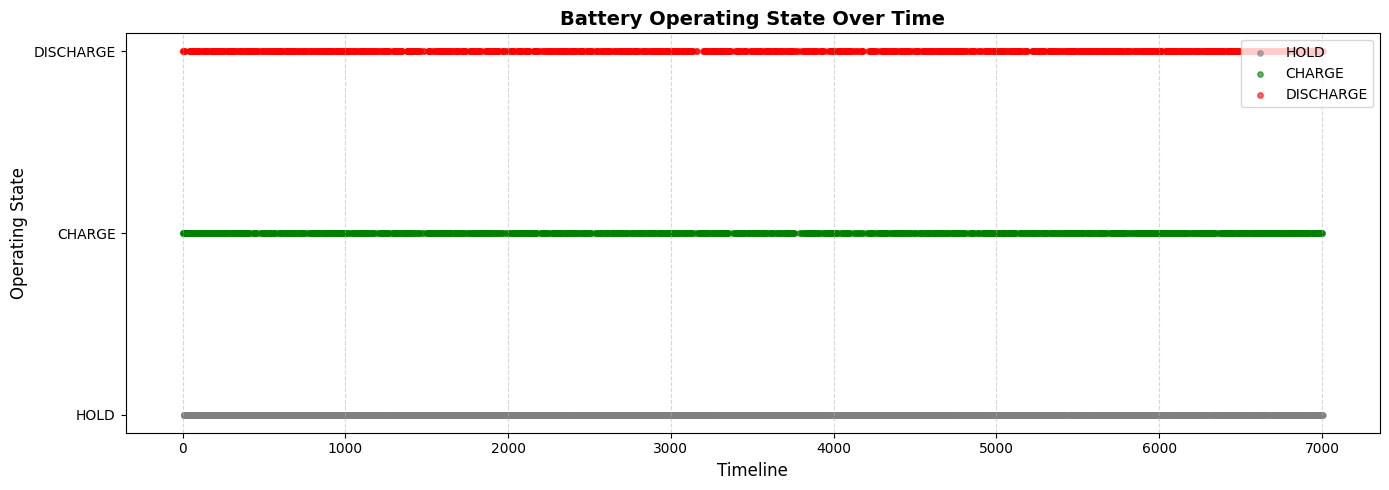

In [740]:
# create a time or index axis for plotting
time_axis = summary_df["SETTLEMENTDATE"].to_numpy() if "SETTLEMENTDATE" in summary_df.columns else np.arange(len(actions))

# battery state timeline
plt.figure(figsize=(14, 5))

colors = {"HOLD": "gray", "CHARGE": "green", "DISCHARGE": "red"}
for action_type in ["HOLD", "CHARGE", "DISCHARGE"]:
    mask = np.array(actions) == action_type
    plt.scatter(time_axis[mask], [action_type] * mask.sum(), 
                label=action_type, color=colors[action_type], alpha=0.6, s=15)

plt.title("Battery Operating State Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Operating State", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

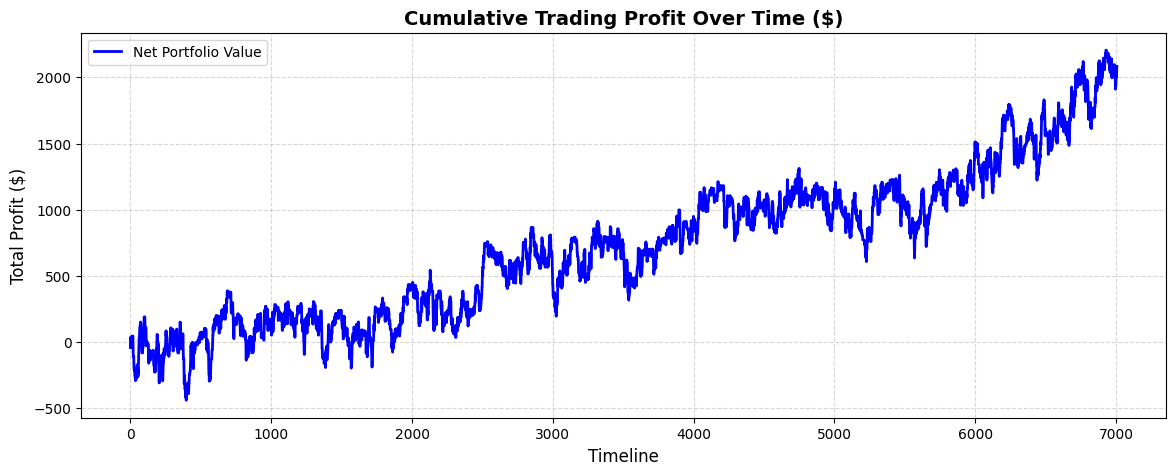

In [741]:
# cumulative trading profit
plt.figure(figsize=(14, 5))
plt.plot(time_axis, profit_history, color="blue", linewidth=2, label="Net Portfolio Value")

plt.title("Cumulative Trading Profit Over Time ($)", fontsize=14, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.show()

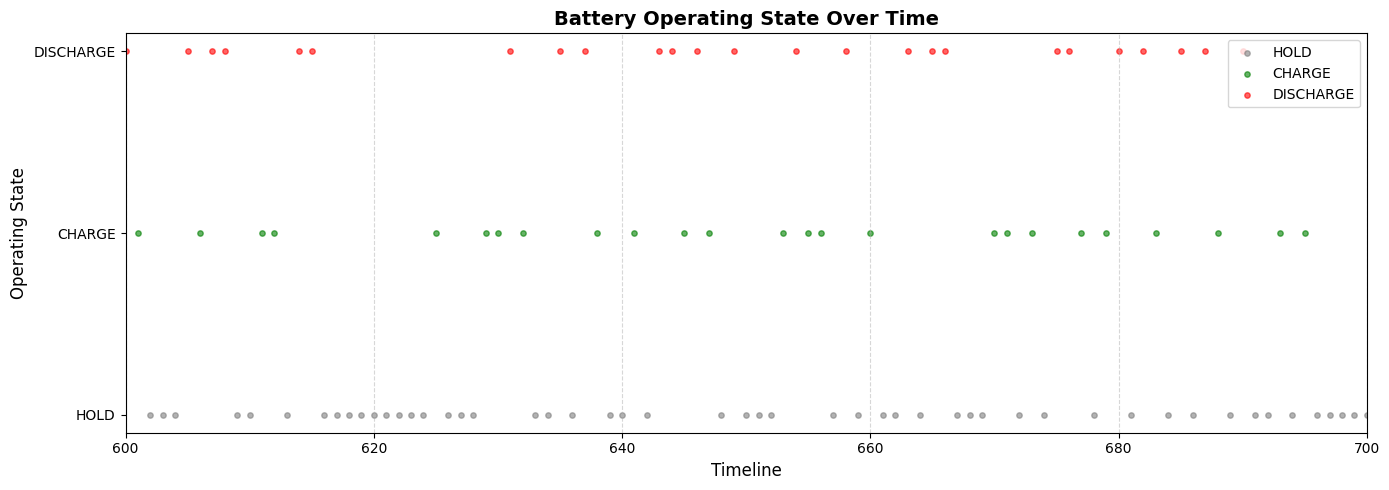

In [742]:
# closer look at battery state timeline
plt.figure(figsize=(14, 5))

colors = {"HOLD": "gray", "CHARGE": "green", "DISCHARGE": "red"}
for action_type in ["HOLD", "CHARGE", "DISCHARGE"]:
    mask = np.array(actions) == action_type
    plt.scatter(time_axis[mask], [action_type] * mask.sum(), 
                label=action_type, color=colors[action_type], alpha=0.6, s=15)

plt.title("Battery Operating State Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Operating State", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.xlim(time_axis[600], time_axis[700]) # shortened to observe behaviour closer
plt.tight_layout()
plt.show()